# Mandelbrot Set

Renders a 600×450 colour Mandelbrot image directly in the notebook using `lfortran_display`.

The `lfortran_display` module is injected automatically at kernel startup (in `configure_impl`),
so `use lfortran_display` works in every cell without any extra setup.

`display_image(w, h, rgba)` accepts a Fortran array `rgba(4, w, h)` with integer RGBA channels
and renders it as a BMP image in the Jupyter frontend — the Fortran equivalent of
`xcpp::display(image)` in xeus-cpp.

In [1]:
1 + 1

2

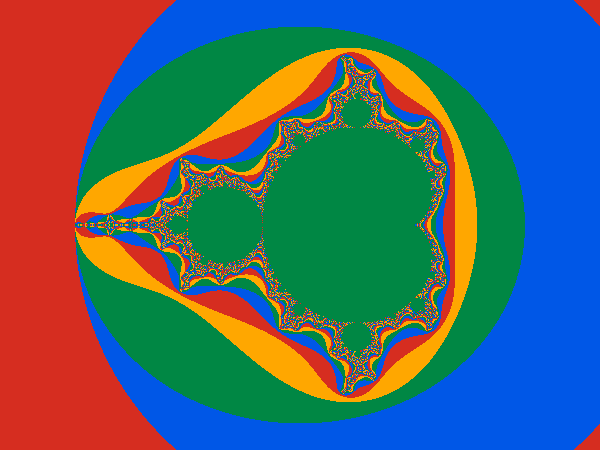

In [2]:
use lfortran_display, only: display_image
integer, parameter :: Nx = 600, Ny = 450, n_max = 255, dp = kind(0.d0)
real(dp), parameter :: xcenter = -0.5_dp, ycenter = 0.0_dp, &
    width = 4.0_dp, height = 3.0_dp, &
    dx_di = width/Nx, dy_dj = -height/Ny, &
    x_offset = xcenter - (Nx+1)*dx_di/2, &
    y_offset = ycenter - (Ny+1)*dy_dj/2
integer :: image(Nx,Ny), image_color(4,Nx,Ny), palette(3,4), i, j, n, idx
real(dp) :: x, y, x_0, y_0, x_sqr, y_sqr

! Compute escape iteration count for each pixel
do j = 1, Ny
    y_0 = y_offset + dy_dj * j
    do i = 1, Nx
        x_0 = x_offset + dx_di * i
        x = 0; y = 0; n = 0
        do
            x_sqr = x ** 2; y_sqr = y ** 2
            if (x_sqr + y_sqr > 4 .or. n == n_max) then
                image(i,j) = 255-n
                exit
            end if
            y = y_0 + 2 * x * y
            x = x_0 + x_sqr - y_sqr
            n = n + 1
        end do
    end do
end do

! 4-colour palette
palette(1,1) =   0; palette(2,1) = 135; palette(3,1) =  68
palette(1,2) =   0; palette(2,2) =  87; palette(3,2) = 231
palette(1,3) = 214; palette(2,3) =  45; palette(3,3) =  32
palette(1,4) = 255; palette(2,4) = 167; palette(3,4) =   0

! Map escape count → RGBA colour
do j = 1, Ny
    do i = 1, Nx
        idx = mod(image(i,j), 4) + 1
        image_color(1,i,j) = palette(1,idx)  ! R
        image_color(2,i,j) = palette(2,idx)  ! G
        image_color(3,i,j) = palette(3,idx)  ! B
        image_color(4,i,j) = 255             ! A
    end do
end do

call display_image(Nx, Ny, image_color)